VECTOR SEARCH WITH PCA AND SVD - COMPLETE DEMONSTRATION

1. Initializing Vector Search Engine

2. Building Dataset
Generating dataset...
Generated 500 sentences

Sample sentences:
  1. Digital twins create virtual replicas of physical systems for simulation This relates to user experience implementations.
  2. Economic impact of computer vision algorithms help machines interpret and understand visual information
  3. Natural language processing enables computers to understand and generate human language This relates to speech recognition systems implementations.

3. Preprocessing Sentences
Converting sentences to vectors...
TF-IDF matrix shape: (500, 200)
Vocabulary size: 200

4. Applying Dimensionality Reduction
--------------------------------------------------

Applying PCA...
Reducing from 200 to 50 dimensions

Using custom PCA implementation...

Using sklearn PCA...

Custom PCA time: 0.6110s
Sklearn PCA time: 0.1602s
Speedup: 3.81x

5. Testing SVD Implementation
------------------

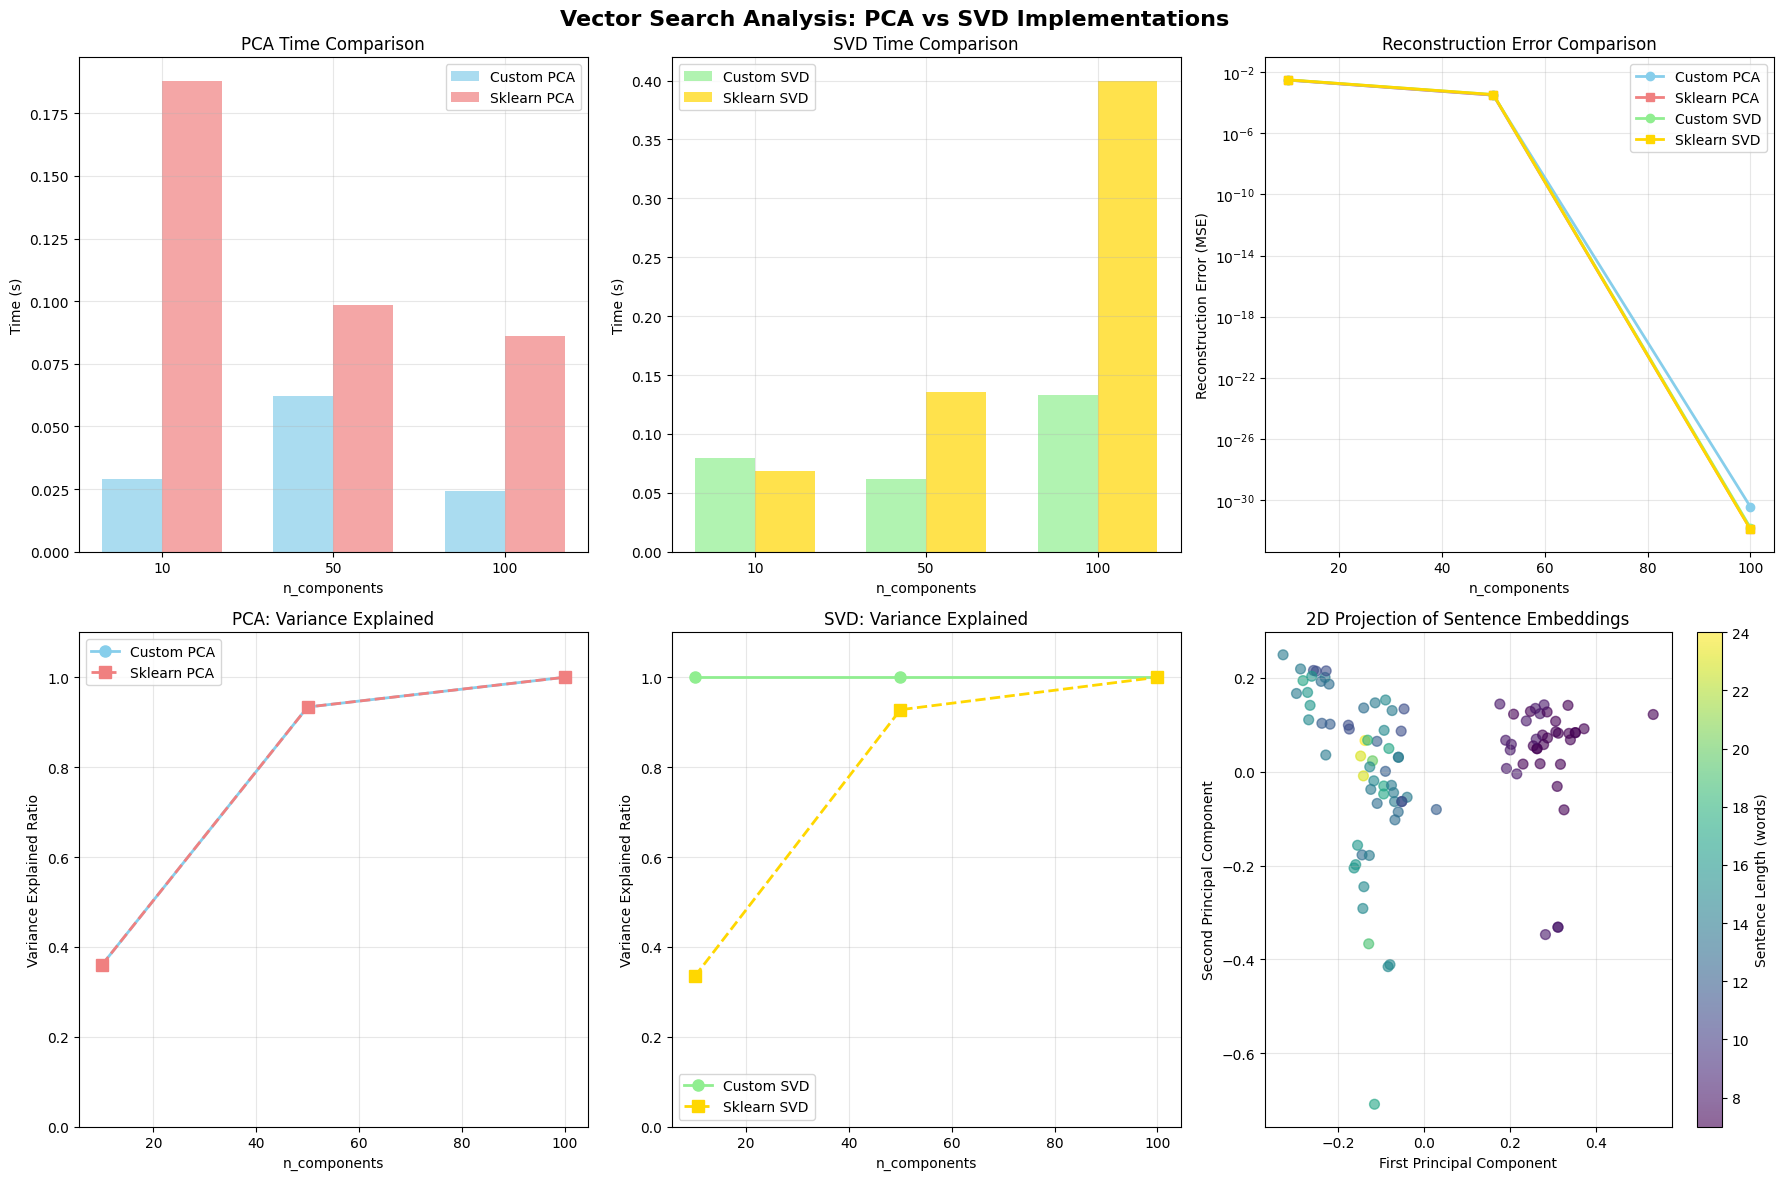


8. Vector Search Demonstration
--------------------------------------------------

Query: 'machine learning algorithms'
----------------------------------------

PCA Search Results:
  1. [0.8143] This paper analyzes machine learning algorithms in detail....
  2. [0.8140] This paper explores machine learning algorithms in detail....
  3. [0.7999] This paper reviews machine learning algorithms in detail....

SVD Search Results:
  1. [0.8221] This paper analyzes machine learning algorithms in detail....
  2. [0.8209] This paper explores machine learning algorithms in detail....
  3. [0.8090] This paper reviews machine learning algorithms in detail....

Query: 'data analysis techniques'
----------------------------------------

PCA Search Results:
  1. [0.5714] This paper explores cryptographic techniques in detail....
  2. [0.5683] This paper discusses cryptographic techniques in detail....
  3. [0.5657] This paper analyzes cryptographic techniques in detail....

SVD Search Results:
  1.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as SKPCA
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import seaborn as sns
from scipy import linalg
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

class CustomPCA:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None

    def fit(self, X):
        # Centering  the data
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # Computing covariance matrix
        n_samples = X.shape[0]
        covariance_matrix = (X_centered.T @ X_centered) / (n_samples - 1)

        # Computing eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

        # Sorting eigenvalues and eigenvectors in descending order
        sorted_indices = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]

        # Selecting  n_components - handle case where n_components > available components
        max_components = min(X.shape[0], X.shape[1])
        if self.n_components is not None:
            self.n_components = min(self.n_components, max_components)
            self.components_ = eigenvectors[:, :self.n_components]
            self.explained_variance_ = eigenvalues[:self.n_components]
        else:
            self.n_components = max_components
            self.components_ = eigenvectors
            self.explained_variance_ = eigenvalues

        # Calculating explained variance ratio
        total_variance = np.sum(eigenvalues)
        self.explained_variance_ratio_ = self.explained_variance_ / total_variance

        return self

    def transform(self, X):
        """Transforming data using fitted PCA"""
        X_centered = X - self.mean_
        return X_centered @ self.components_

    def fit_transform(self, X):
        """Fiting and transforming data"""
        self.fit(X)
        return self.transform(X)

class CustomSVD:
    """Customing SVD implementation """

    def __init__(self, n_components=None):
        self.n_components = n_components
        self.U = None
        self.S = None
        self.Vt = None

    def fit(self, X):
        """Fiting SVD to the data"""
        # SVD
        U, S, Vt = np.linalg.svd(X, full_matrices=False)

        # Storing results
        self.U = U
        self.S = S
        self.Vt = Vt

        # Truncating if n_components is specified
        max_components = min(X.shape[0], X.shape[1])
        if self.n_components is not None:
            self.n_components = min(self.n_components, max_components)
            self.U = U[:, :self.n_components]
            self.S = S[:self.n_components]
            self.Vt = Vt[:self.n_components, :]
        else:
            self.n_components = max_components

        return self

    def transform(self, X):
        """Transforming data using fitted SVD"""
        return X @ self.Vt[:self.n_components, :].T

    def fit_transform(self, X):
        """Fitting and transforming data"""
        self.fit(X)
        return self.transform(X)

class VectorSearchEngine:
    """Vector search engine using dimensionality reduction"""

    def __init__(self, method='pca', n_components=None):
        self.method = method
        self.n_components = n_components
        # Increase max_features to get more dimensions
        self.vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
        self.reducer = None
        self.embeddings = None
        self.sentences = None

    def build_dataset(self, n_samples=1000):
        """Generating a dataset of sentences"""
        print("Generating dataset...")

        # More diverse base sentences to increase vocabulary
        base_sentences = [
            "The quick brown fox jumps over the lazy dog while the sun sets in the western horizon",
            "Machine learning and artificial intelligence are transforming modern technology applications",
            "Data science encompasses statistics, programming, and domain knowledge for insights",
            "Natural language processing enables computers to understand and generate human language",
            "Deep learning architectures use neural networks with multiple hidden layers for complex tasks",
            "Python programming language is widely used for data analysis and scientific computing",
            "Computer vision algorithms help machines interpret and understand visual information",
            "Big data technologies require distributed computing frameworks for processing",
            "Reinforcement learning agents optimize behavior through environmental interactions",
            "Cloud computing platforms provide scalable infrastructure and services",
            "Quantum computing uses quantum bits to perform complex calculations exponentially faster",
            "Cybersecurity measures protect digital systems from unauthorized access and attacks",
            "Internet of Things connects physical devices to exchange data over networks",
            "Blockchain technology creates decentralized and secure digital ledgers",
            "Augmented reality overlays digital information onto the physical world",
            "Autonomous vehicles use sensors and algorithms to navigate without human input",
            "Robotic process automation streamlines repetitive business tasks efficiently",
            "Edge computing processes data closer to the source reducing latency",
            "5G networks provide faster wireless communication with lower latency",
            "Digital twins create virtual replicas of physical systems for simulation"
        ]

        # More variations for diversity
        variations = [
            "This comprehensive article discusses ",
            "Recent research demonstrates that ",
            "The scientific community explores ",
            "Industry applications include ",
            "Educational resources cover ",
            "Technological advancements in ",
            "Future developments of ",
            "Historical perspective on ",
            "Comparative analysis of ",
            "Critical examination of ",
            "Practical implementation of ",
            "Theoretical foundations of ",
            "Methodological approaches to ",
            "Experimental results from ",
            "Case studies involving ",
            "Best practices for ",
            "Challenges and solutions in ",
            "Ethical considerations of ",
            "Economic impact of ",
            "Social implications of "
        ]

        # Adding more topics
        topics = [
            "machine learning algorithms", "deep neural networks", "data visualization",
            "statistical analysis", "predictive modeling", "computer vision applications",
            "natural language understanding", "speech recognition systems", "robotic automation",
            "cybersecurity protocols", "cloud infrastructure", "database management",
            "web development frameworks", "mobile application design", "user experience",
            "software engineering principles", "algorithm optimization", "computational complexity",
            "mathematical modeling", "scientific computing", "quantum algorithms",
            "cryptographic techniques", "network architecture", "distributed systems",
            "parallel computing", "GPU acceleration", "edge computing applications"
        ]

        sentences = []
        for i in range(n_samples):
            # Combining different patterns
            pattern = np.random.choice(['variation_base', 'topic_discussion', 'combined'])

            if pattern == 'variation_base':
                base = np.random.choice(base_sentences)
                variation = np.random.choice(variations)
                sentence = variation + base.lower()

            elif pattern == 'topic_discussion':
                topic = np.random.choice(topics)
                action = np.random.choice(['explores', 'analyzes', 'discusses', 'examines', 'reviews'])
                sentence = f"This paper {action} {topic} in detail."

            else:  # combined
                base = np.random.choice(base_sentences)
                topic = np.random.choice(topics)
                sentence = f"{base} This relates to {topic} implementations."

            # Adding some noise/typos occasionally
            if np.random.random() < 0.05:
                words = sentence.split()
                if len(words) > 2:
                    idx = np.random.randint(0, len(words))
                    # Only modifying longer words
                    if len(words[idx]) > 4:
                        # Removeing last character or add typo
                        if np.random.random() < 0.5:
                            words[idx] = words[idx][:-1]
                        else:
                            # Adding duplicate letter
                            pos = np.random.randint(0, len(words[idx])-1)
                            words[idx] = words[idx][:pos] + words[idx][pos] + words[idx][pos:]
                sentence = ' '.join(words)

            sentences.append(sentence)

        self.sentences = sentences
        print(f"Generated {len(sentences)} sentences")
        return sentences

    def preprocess(self, sentences):
        """Converting sentences to vector representations"""
        print("Converting sentences to vectors...")
        tfidf_matrix = self.vectorizer.fit_transform(sentences)
        self.vocab = self.vectorizer.get_feature_names_out()
        dense_matrix = tfidf_matrix.toarray()
        print(f"TF-IDF matrix shape: {dense_matrix.shape}")
        print(f"Vocabulary size: {len(self.vocab)}")
        return dense_matrix

    def reduce_dimensionality(self, vectors, method='pca'):
        """Applying dimensionality reduction"""
        print(f"\nApplying {method.upper()}...")

        # Determine max possible components
        max_components = min(vectors.shape[0], vectors.shape[1])
        if self.n_components is None:
            self.n_components = min(50, max_components)
        else:
            self.n_components = min(self.n_components, max_components)

        print(f"Reducing from {vectors.shape[1]} to {self.n_components} dimensions")

        if method == 'pca':
            # Custom PCA
            print("\nUsing custom PCA implementation...")
            start_time = time.time()
            self.custom_pca = CustomPCA(n_components=self.n_components)
            custom_reduced = self.custom_pca.fit_transform(vectors)
            custom_time = time.time() - start_time

            # sklearn PCA - handle n_components properly
            print("\nUsing sklearn PCA...")
            start_time = time.time()
            sklearn_n_components = min(self.n_components, vectors.shape[1]-1)  # sklearn requires n_components <= min(n_samples, n_features)
            self.sklearn_pca = SKPCA(n_components=sklearn_n_components, random_state=42)
            sklearn_reduced = self.sklearn_pca.fit_transform(vectors)
            sklearn_time = time.time() - start_time

            print(f"\nCustom PCA time: {custom_time:.4f}s")
            print(f"Sklearn PCA time: {sklearn_time:.4f}s")
            print(f"Speedup: {custom_time/sklearn_time:.2f}x")

            self.embeddings = custom_reduced
            self.reducer = 'pca'

            return {
                'custom': custom_reduced,
                'sklearn': sklearn_reduced,
                'times': {'custom': custom_time, 'sklearn': sklearn_time}
            }

        elif method == 'svd':
            # Custom SVD
            print("\nUsing custom SVD implementation...")
            start_time = time.time()
            self.custom_svd = CustomSVD(n_components=self.n_components)
            custom_reduced = self.custom_svd.fit_transform(vectors)
            custom_time = time.time() - start_time

            # sklearn TruncatedSVD
            print("\nUsing sklearn TruncatedSVD...")
            start_time = time.time()
            self.sklearn_svd = TruncatedSVD(n_components=self.n_components, random_state=42)
            sklearn_reduced = self.sklearn_svd.fit_transform(vectors)
            sklearn_time = time.time() - start_time

            print(f"\nCustom SVD time: {custom_time:.4f}s")
            print(f"Sklearn SVD time: {sklearn_time:.4f}s")
            print(f"Speedup: {custom_time/sklearn_time:.2f}x")

            self.embeddings = custom_reduced
            self.reducer = 'svd'

            return {
                'custom': custom_reduced,
                'sklearn': sklearn_reduced,
                'times': {'custom': custom_time, 'sklearn': sklearn_time}
            }

    def search(self, query, top_k=5):
        """Searching for similar sentences"""
        if self.embeddings is None:
            raise ValueError("Please train the model first")

        # Converting query to vector
        query_vec = self.vectorizer.transform([query]).toarray()

        # Reducing query dimensionality
        if self.reducer == 'pca':
            query_embedding = self.custom_pca.transform(query_vec)
        else:  # svd
            query_embedding = self.custom_svd.transform(query_vec)

        # Calculating cosine similarities
        similarities = []
        query_norm = np.linalg.norm(query_embedding)

        for i, emb in enumerate(self.embeddings):
            if query_norm == 0 or np.linalg.norm(emb) == 0:
                sim = 0
            else:
                sim = np.dot(query_embedding.flatten(), emb) / (query_norm * np.linalg.norm(emb))
            similarities.append((i, sim))

        # Sorting by similarity
        similarities.sort(key=lambda x: x[1], reverse=True)

        # Returning top results
        results = []
        for idx, sim in similarities[:top_k]:
            results.append({
                'sentence': self.sentences[idx],
                'similarity': sim,
                'index': idx
            })

        return results

def evaluate_implementations(vectors, n_components_list=[10, 50, 100]):
    """Comparing custom and sklearn implementations"""

    results = []
    max_components = min(vectors.shape[0], vectors.shape[1])

    # Adjusting n_components_list based on available dimensions
    n_components_list = [n for n in n_components_list if n <= max_components]
    if not n_components_list:
        n_components_list = [max_components // 2, max_components]

    for n_comp in n_components_list:
        print(f"\n{'='*60}")
        print(f"Evaluating with n_components={n_comp}")
        print(f"{'='*60}")

        # PCA comparison
        print("\nPCA Comparison:")
        custom_pca = CustomPCA(n_components=n_comp)
        sklearn_pca = SKPCA(n_components=min(n_comp, vectors.shape[1]-1), random_state=42)

        # Time custom PCA
        start = time.time()
        custom_pca.fit(vectors)
        custom_pca_time = time.time() - start

        # Time sklearn PCA
        start = time.time()
        sklearn_pca.fit(vectors)
        sklearn_pca_time = time.time() - start

        # Calculating reconstruction error for both
        custom_transformed = custom_pca.transform(vectors)
        sklearn_transformed = sklearn_pca.transform(vectors)

        custom_reconstructed = custom_transformed @ custom_pca.components_.T + custom_pca.mean_
        sklearn_reconstructed = sklearn_transformed @ sklearn_pca.components_ + sklearn_pca.mean_

        custom_error = np.mean((vectors - custom_reconstructed) ** 2)
        sklearn_error = np.mean((vectors - sklearn_reconstructed) ** 2)

        results.append({
            'method': 'PCA',
            'n_components': n_comp,
            'custom_time': custom_pca_time,
            'sklearn_time': sklearn_pca_time,
            'custom_error': custom_error,
            'sklearn_error': sklearn_error,
            'custom_variance_ratio': np.sum(custom_pca.explained_variance_ratio_),
            'sklearn_variance_ratio': np.sum(sklearn_pca.explained_variance_ratio_)
        })

        print(f"Custom PCA variance explained: {np.sum(custom_pca.explained_variance_ratio_):.4f}")
        print(f"Sklearn PCA variance explained: {np.sum(sklearn_pca.explained_variance_ratio_):.4f}")

        # SVD comparison
        print("\nSVD Comparison:")
        custom_svd = CustomSVD(n_components=n_comp)
        sklearn_svd = TruncatedSVD(n_components=n_comp, random_state=42)

        # Time custom SVD
        start = time.time()
        custom_svd.fit(vectors)
        custom_svd_time = time.time() - start

        # Time sklearn SVD
        start = time.time()
        sklearn_svd.fit(vectors)
        sklearn_svd_time = time.time() - start

        # Calculatimg reconstruction error for both
        custom_svd_transformed = custom_svd.transform(vectors)
        sklearn_svd_transformed = sklearn_svd.transform(vectors)

        custom_svd_reconstructed = custom_svd_transformed @ custom_svd.Vt
        sklearn_svd_reconstructed = sklearn_svd_transformed @ sklearn_svd.components_

        custom_svd_error = np.mean((vectors - custom_svd_reconstructed) ** 2)
        sklearn_svd_error = np.mean((vectors - sklearn_svd_reconstructed) ** 2)

        # Calculating variance explained for SVD
        if custom_svd.S is not None:
            total_variance = np.sum(custom_svd.S ** 2)
            explained_variance = np.sum(custom_svd.S[:n_comp] ** 2)
            custom_variance_ratio = explained_variance / total_variance if total_variance > 0 else 0
        else:
            custom_variance_ratio = 0

        results.append({
            'method': 'SVD',
            'n_components': n_comp,
            'custom_time': custom_svd_time,
            'sklearn_time': sklearn_svd_time,
            'custom_error': custom_svd_error,
            'sklearn_error': sklearn_svd_error,
            'custom_variance_ratio': custom_variance_ratio,
            'sklearn_variance_ratio': np.sum(sklearn_svd.explained_variance_ratio_)
        })

        print(f"Custom SVD variance explained: {custom_variance_ratio:.4f}")
        print(f"Sklearn SVD variance explained: {np.sum(sklearn_svd.explained_variance_ratio_):.4f}")

    return pd.DataFrame(results)

def create_visualizations(df_results, vectors, engine):
    """Creating visualization plots"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Time comparison
    ax = axes[0, 0]
    pca_times = df_results[df_results['method'] == 'PCA']
    svd_times = df_results[df_results['method'] == 'SVD']

    if not pca_times.empty:
        x = range(len(pca_times))
        width = 0.35

        ax.bar([i - width/2 for i in x], pca_times['custom_time'], width,
               label='Custom PCA', alpha=0.7, color='skyblue')
        ax.bar([i + width/2 for i in x], pca_times['sklearn_time'], width,
               label='Sklearn PCA', alpha=0.7, color='lightcoral')
        ax.set_xlabel('n_components')
        ax.set_ylabel('Time (s)')
        ax.set_title('PCA Time Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(pca_times['n_components'])
        ax.legend()
        ax.grid(True, alpha=0.3)

    # 2. SVD Time comparison
    ax = axes[0, 1]
    if not svd_times.empty:
        x = range(len(svd_times))
        width = 0.35

        ax.bar([i - width/2 for i in x], svd_times['custom_time'], width,
               label='Custom SVD', alpha=0.7, color='lightgreen')
        ax.bar([i + width/2 for i in x], svd_times['sklearn_time'], width,
               label='Sklearn SVD', alpha=0.7, color='gold')
        ax.set_xlabel('n_components')
        ax.set_ylabel('Time (s)')
        ax.set_title('SVD Time Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(svd_times['n_components'])
        ax.legend()
        ax.grid(True, alpha=0.3)

    # 3. Error comparison
    ax = axes[0, 2]
    if not pca_times.empty and not svd_times.empty:
        ax.plot(pca_times['n_components'], pca_times['custom_error'], 'o-',
                label='Custom PCA', color='skyblue', linewidth=2)
        ax.plot(pca_times['n_components'], pca_times['sklearn_error'], 's-',
                label='Sklearn PCA', color='lightcoral', linewidth=2)
        ax.plot(svd_times['n_components'], svd_times['custom_error'], 'o-',
                label='Custom SVD', color='lightgreen', linewidth=2)
        ax.plot(svd_times['n_components'], svd_times['sklearn_error'], 's-',
                label='Sklearn SVD', color='gold', linewidth=2)
        ax.set_xlabel('n_components')
        ax.set_ylabel('Reconstruction Error (MSE)')
        ax.set_title('Reconstruction Error Comparison')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')

    # 4. Variance explained - PCA
    ax = axes[1, 0]
    if not pca_times.empty:
        ax.plot(pca_times['n_components'], pca_times['custom_variance_ratio'], 'o-',
                label='Custom PCA', color='skyblue', linewidth=2, markersize=8)
        ax.plot(pca_times['n_components'], pca_times['sklearn_variance_ratio'], 's--',
                label='Sklearn PCA', color='lightcoral', linewidth=2, markersize=8)
        ax.set_xlabel('n_components')
        ax.set_ylabel('Variance Explained Ratio')
        ax.set_title('PCA: Variance Explained')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.1])

    # 5. Variance explained - SVD
    ax = axes[1, 1]
    if not svd_times.empty:
        ax.plot(svd_times['n_components'], svd_times['custom_variance_ratio'], 'o-',
                label='Custom SVD', color='lightgreen', linewidth=2, markersize=8)
        ax.plot(svd_times['n_components'], svd_times['sklearn_variance_ratio'], 's--',
                label='Sklearn SVD', color='gold', linewidth=2, markersize=8)
        ax.set_xlabel('n_components')
        ax.set_ylabel('Variance Explained Ratio')
        ax.set_title('SVD: Variance Explained')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.1])

    # 6. 2D visualization of embeddings
    ax = axes[1, 2]
    if engine.embeddings is not None and engine.embeddings.shape[1] >= 2:
        #  a sample for visualization
        if engine.embeddings.shape[0] > 100:
            sample_indices = np.random.choice(engine.embeddings.shape[0], 100, replace=False)
        else:
            sample_indices = np.arange(engine.embeddings.shape[0])

        # first two dimensions
        x = engine.embeddings[sample_indices, 0]
        y = engine.embeddings[sample_indices, 1]

        # Color by sentence length
        lengths = [len(engine.sentences[i].split()) for i in sample_indices]

        scatter = ax.scatter(x, y, c=lengths, cmap='viridis', alpha=0.6, s=50)
        ax.set_xlabel('First Principal Component')
        ax.set_ylabel('Second Principal Component')
        ax.set_title('2D Projection of Sentence Embeddings')
        ax.grid(True, alpha=0.3)

        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Sentence Length (words)')

    plt.suptitle('Vector Search Analysis: PCA vs SVD Implementations', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('vector_search_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    return fig

def run_demo():
    """Runing a complete demonstration"""
    print("=" * 70)
    print("VECTOR SEARCH WITH PCA AND SVD - COMPLETE DEMONSTRATION")
    print("=" * 70)

    # Initializing  search engine
    print("\n1. Initializing Vector Search Engine")
    engine = VectorSearchEngine(method='pca', n_components=50)

    # Building dataset
    print("\n2. Building Dataset")
    sentences = engine.build_dataset(n_samples=500)

    print(f"\nSample sentences:")
    for i in range(3):
        print(f"  {i+1}. {sentences[i]}")

    # Preprocess
    print("\n3. Preprocessing Sentences")
    vectors = engine.preprocess(sentences)

    # Apply PCA and compare
    print("\n4. Applying Dimensionality Reduction")
    print("-" * 50)
    pca_results = engine.reduce_dimensionality(vectors, method='pca')

    # Also test SVD
    print("\n5. Testing SVD Implementation")
    print("-" * 50)
    engine_svd = VectorSearchEngine(method='svd', n_components=50)
    engine_svd.sentences = sentences
    vectors_svd = engine_svd.preprocess(sentences)
    svd_results = engine_svd.reduce_dimensionality(vectors_svd, method='svd')

    # Evaluating implementations
    print("\n6. Comprehensive Evaluation")
    print("-" * 50)
    df_results = evaluate_implementations(vectors)

    print("\nEvaluation Results Summary:")
    print("-" * 50)
    print(df_results[['method', 'n_components', 'custom_time', 'sklearn_time',
                     'custom_variance_ratio', 'sklearn_variance_ratio']].to_string())

    # Creating visualizations
    print("\n7. Generating Visualizations")
    print("-" * 50)
    fig = create_visualizations(df_results, vectors, engine)

    # Demo search with both methods
    print("\n8. Vector Search Demonstration")
    print("-" * 50)

    test_queries = [
        "machine learning algorithms",
        "data analysis techniques",
        "neural networks and deep learning",
        "cloud computing applications"
    ]

    for query in test_queries:
        print(f"\nQuery: '{query}'")
        print("-" * 40)

        # PCA search
        print("\nPCA Search Results:")
        pca_results = engine.search(query, top_k=3)
        for i, result in enumerate(pca_results):
            print(f"  {i+1}. [{result['similarity']:.4f}] {result['sentence'][:80]}...")

        # SVD search
        print("\nSVD Search Results:")
        svd_results = engine_svd.search(query, top_k=3)
        for i, result in enumerate(svd_results):
            print(f"  {i+1}. [{result['similarity']:.4f}] {result['sentence'][:80]}...")

    # Mathematical validation
    print("\n9. Mathematical Validation")
    print("-" * 50)

    # Check PCA orthogonality
    if hasattr(engine, 'custom_pca') and engine.custom_pca.components_ is not None:
        V = engine.custom_pca.components_
        orthogonality_error = np.linalg.norm(V.T @ V - np.eye(V.shape[1]))
        print(f"\nPCA Orthogonality Check:")
        print(f"  ||VᵀV - I|| = {orthogonality_error:.2e}")
        print(f"  Components are {'orthogonal' if orthogonality_error < 1e-10 else 'not perfectly orthogonal'}")

    # Check SVD properties
    if hasattr(engine_svd, 'custom_svd') and engine_svd.custom_svd.Vt is not None:
        V = engine_svd.custom_svd.Vt.T
        orthogonality_error = np.linalg.norm(V.T @ V - np.eye(V.shape[1]))
        print(f"\nSVD Orthogonality Check:")
        print(f"  ||VᵀV - I|| = {orthogonality_error:.2e}")
        print(f"  Components are {'orthogonal' if orthogonality_error < 1e-10 else 'not perfectly orthogonal'}")

    return engine, engine_svd, df_results

if __name__ == "__main__":
    # Runing the complete demonstration
    engine_pca, engine_svd, results_df = run_demo()

    # Save  to CSV
    results_df.to_csv('vector_search_results.csv', index=False)
    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    print(f"✓ Generated dataset: {len(engine_pca.sentences)} sentences")
    print(f"✓ Vocabulary size: {len(engine_pca.vocab)} words")
    print(f"✓ TF-IDF dimensions: {engine_pca.embeddings.shape[1] if engine_pca.embeddings is not None else 'N/A'}")
    print(f"✓ Results saved to 'vector_search_results.csv'")
    print(f"✓ Visualization saved to 'vector_search_analysis.png'")
    print("\nProject completed successfully!")

